# March Madness Rating Computation

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import lightgbm as lgb
import xgboost as xgb
from autoxgb import AutoXGB
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, brier_score_loss, mean_absolute_error, log_loss
from scipy.interpolate import UnivariateSpline, InterpolatedUnivariateSpline # interpolate win margin model to probabilities
from datetime import datetime
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, RobustScaler, MinMaxScaler


/Users/danw/dansCode/TennisPredictionModel/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
start = '20120101'
end = '20231231'
match_type = 'm'

In [3]:
start_date = datetime.strptime(start, '%Y%m%d').date()
end_date = datetime.strptime(end, '%Y%m%d').date()

RD_CUTOFF = 360

df = pd.read_csv('../../testcsvs/StephWFixDouble25.csv')
df['tourney_date'] = pd.to_datetime(df['tourney_date']).dt.date
df = df[(df['tourney_date'] >= start_date) & (df['tourney_date'] <= end_date)]
# df = df[(df['a_glicko_rd'] <= RD_CUTOFF) & (df['b_glicko_rd'] <= RD_CUTOFF)]

df = df.drop(['tourney_id', 'tourney_name', 'match_num', 'tourney_date', 'a_player_name', 'b_player_name', 'a_player_id', 'a_player_slug', 'b_player_id', 'b_player_slug', 'sets', 'games', 'tiebreaks'], axis=1)
# print(df.duplicated().sum())

print(len(df))

one_hot_encoder = OneHotEncoder(sparse_output=False)

# One-Hot Encode the 'category_text' column
category_encoded = one_hot_encoder.fit_transform(df[['surface']])

# Convert to DataFrame
category_encoded_df = pd.DataFrame(category_encoded, columns=one_hot_encoder.get_feature_names_out(['surface']))

# Concatenate the one-hot encoded columns back to the original DataFrame
df = pd.concat([df.reset_index(drop=True), category_encoded_df], axis=1)

# Drop the original 'category_text' column
df.drop('surface', axis=1, inplace=True)
# print(df.duplicated().sum())

print(len(df))

42730
42730


# March Madness teams - team strength overview

In [4]:




# # Normalize features
# # scaler = StandardScaler()
# # X = scaler.fit_transform(X)

# # Split data
# X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
#     X, y, df.index, test_size=0.3, random_state=42
# )

# X_validate, X_test, y_validate, y_test, idx_validate, idx_test = train_test_split(
#     X_temp, y_temp, idx_temp, test_size=0.5, random_state=42
# )

# # Convert to DataFrames for model compatibility
# df_train = pd.DataFrame(X_train, columns=df.columns)
# df_train['Result'] = y_train

# df_validate = pd.DataFrame(X_validate, columns=df.columns)
# df_validate['Result'] = y_validate

# df_test = pd.DataFrame(X_test, columns=df.columns)
# df_test['Result'] = y_test

# # Train model
# selected_features = df_train.columns.drop('Result').tolist()
# model = trainModel(selected_features, df_train, df_validate)

# # Evaluate model
# evaluation_metrics = evaluateModel(model, df_validate, selected_features)

# print(f"Accuracy: {evaluation_metrics['accuracy']:.4f}")
# print(f"AUC: {evaluation_metrics['auc']:.4f}")

# # Feature importance
# importances = model.feature_importance()
# feature_importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
# feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# # Plot feature importance
# plt.figure(figsize=(15, 10))
# plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.title('Feature Importance')
# plt.gca().invert_yaxis()
# plt.show()

# # Save model
# model.save_model('lightgbm_model.txt')

# # Predictions
# y_pred = model.predict(X_test)

# # Ensure correct odds indexing
# odds_test = odds_df.loc[idx_test].values

# # Create results DataFrame
# results_df = pd.DataFrame({
#     'Actual': y_test,
#     'Predicted': y_pred,
#     'A_Odds': odds_test[:, 0],
#     'B_Odds': odds_test[:, 1]
# })

# # Save predictions
# # results_df.to_csv('predictions_with_odds.csv', index=False)

# # Plot ROC curve
# fpr, tpr, _ = roc_curve(y_test, y_pred)  # Use probabilities
# plt.plot(fpr, tpr)
# plt.title("Receiver Operating Characteristics")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.show()

In [5]:
def cauchyobj(preds, dtrain):
    labels = dtrain.get_label()
    c = 5000 
    x =  preds-labels    
    grad = x / (x**2/c**2+1)
    hess = -c**2*(x**2-c**2)/(x**2+c**2)**2
    return grad, hess

In [6]:
# import optuna
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Data preprocessing (as in your original code)
# df = df.dropna()
# odds_df = df[['a_odds', 'b_odds']].copy()
# odds_df.index = df.index
# df = df.drop(columns=['a_odds', 'b_odds', 'a_b_win'])
# y = df.pop('point_diff').values
# X = df.values
# features = df.columns

# # Split once to be reused in all Optuna trials
# x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# dtrain = xgb.DMatrix(x_train, label=y_train)
# dval = xgb.DMatrix(x_val, label=y_val)

# # Define Optuna objective function
# def objective(trial):
#     param = {
#         'booster': 'gbtree',
#         'eval_metric': 'mae',
#         'eta': trial.suggest_float('eta', 0.001, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.3, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
#         'max_depth': trial.suggest_int('max_depth', 2, 10),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 100),
#         'gamma': trial.suggest_float('gamma', 0, 20),
#         'num_parallel_tree': trial.suggest_int('num_parallel_tree', 1, 40),
#     }

#     # You can optionally test your cauchy objective here if needed:
#     # model = xgb.train(param, dtrain, num_boost_round=1000, obj=cauchyobj)
#     model = xgb.train(param, dtrain, num_boost_round=1000)

#     preds = model.predict(dval)
#     mae = mean_absolute_error(y_val, preds)
#     return mae

# # Run Optuna
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50)

# # Best parameters and score
# print("Best MAE:", study.best_value)
# print("Best params:", study.best_params)

# # Train final model with best params
# best_param = study.best_params
# best_param.update({'eval_metric': 'mae', 'booster': 'gbtree'})  # Add fixed params
# model = xgb.train(best_param, dtrain, num_boost_round=1000)

# # Feature importance
# feature_mapping = {f'f{index}': name for index, name in enumerate(features)}
# feature_importance = model.get_score(importance_type='gain')
# readable_importance = {feature_mapping[k]: v for k, v in feature_importance.items()}
# data = pd.DataFrame.from_dict(readable_importance, orient='index', columns=['score'])
# data = data.sort_values(by="score", ascending=False)
# data.nlargest(40, columns="score").plot(kind='barh', figsize=(20, 10))


In [7]:

import goto_conversion

def preprocessed_goto_conversion(listOfOdds, total = 1):
    listOfProbabilities = [1/x for x in listOfOdds]
    isProbSumBelowTotal = sum(listOfProbabilities) < total
    if isProbSumBelowTotal: #input to goto_conversion must be odds where sum of inverse odds exceeds or equals 1
        reversedListOfOdds = [1/(1-x) for x in listOfProbabilities] #unfair odds of losing
        reversedListOfProbabilities = goto_conversion.goto_conversion(reversedListOfOdds, multiplicativeIfUnprudentOdds = True) #convert the unfair odds of losing to fair probabilities of losing
        outputListOfProbabilities = [1-x for x in reversedListOfProbabilities] #convert fair probabilities of losing to fair probabilities of winning
    else:
        outputListOfProbabilities = goto_conversion.goto_conversion(listOfOdds, multiplicativeIfUnprudentOdds = True)
    return outputListOfProbabilities


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[204]	valid_0's l1: 11.8597
MAE: 11.8597


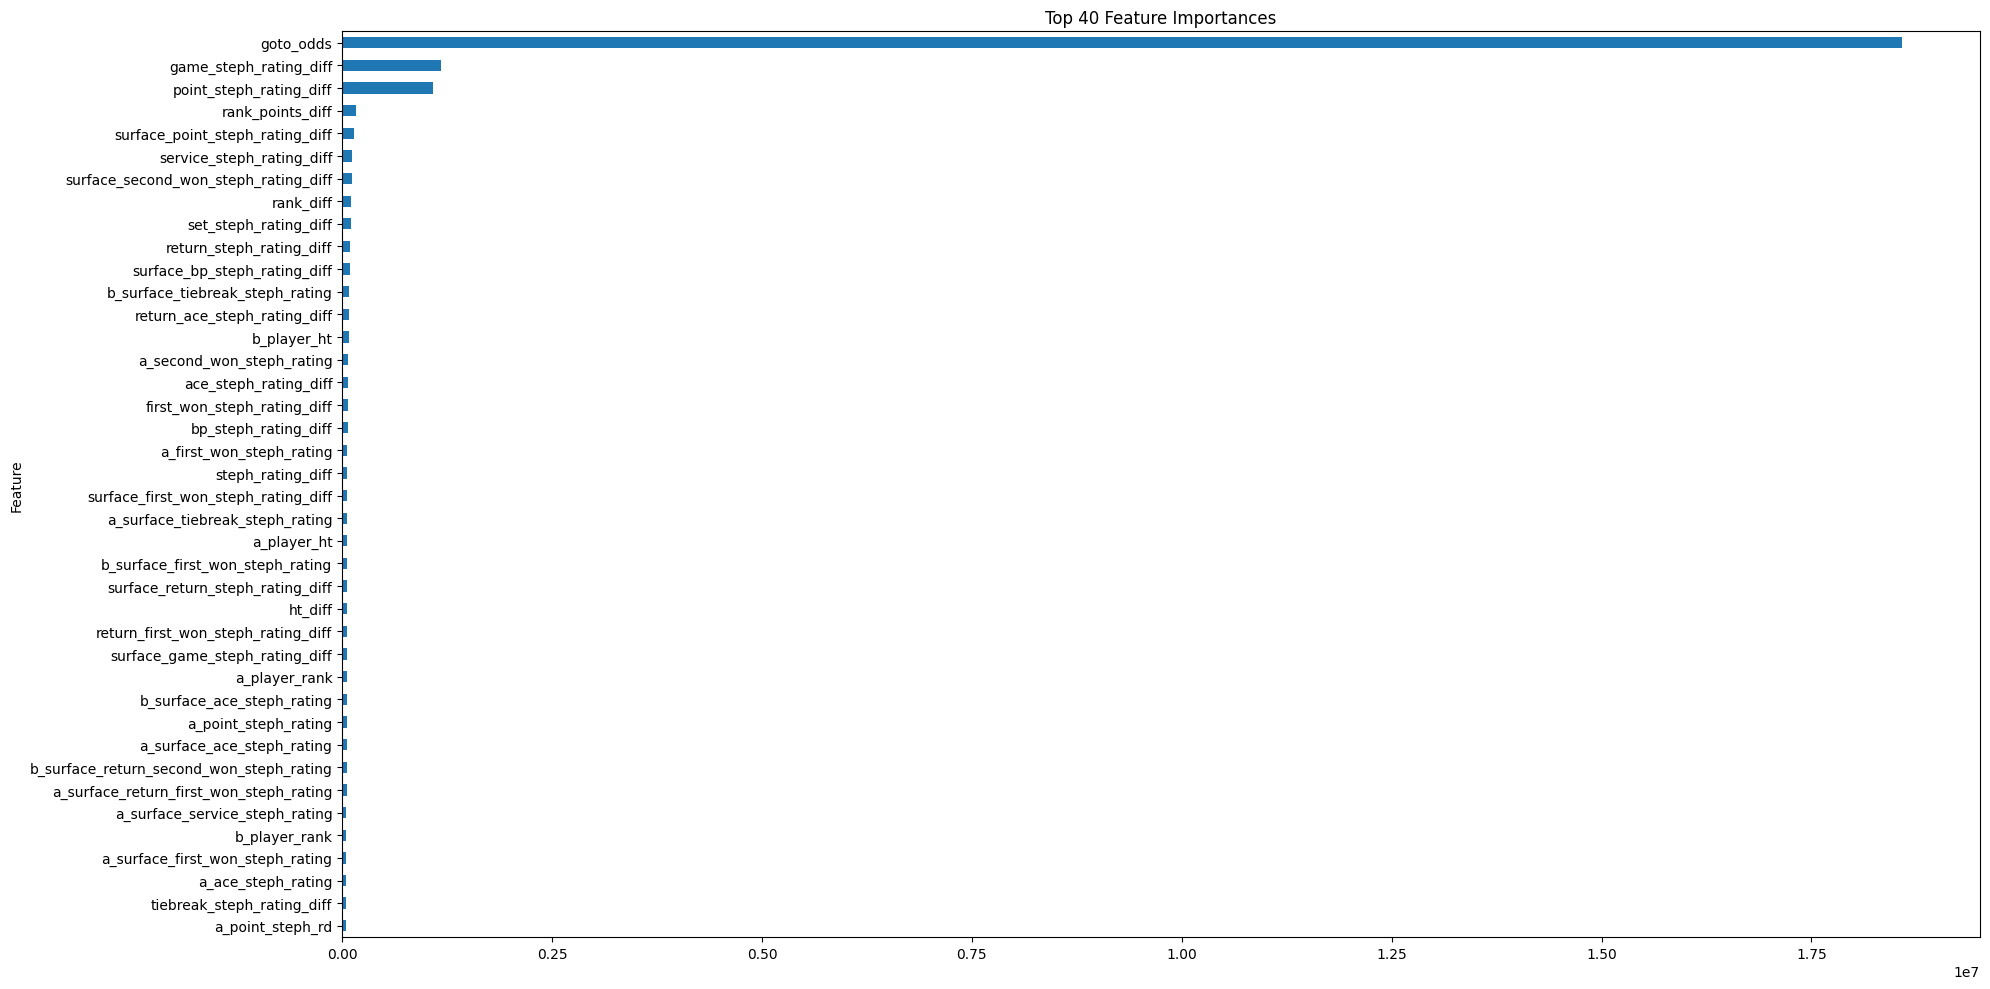

In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# build proxy models to predict win margin
# Data cleaning and filtering
df = df.dropna()

# Uncomment and use if necessary
# df = df[(df['surface_Hard'] == 1.0)]
# df = df[(df['tourney_level'] != 6)]

# Extract odds before dropping them from df
odds_df = df[['a_odds', 'b_odds']].copy()
odds_df.index = df.index  # Ensure proper indexing

# df = df.drop(columns=['a_odds', 'b_odds', 'a_b_win'])  # Remove odds from feature set
# df = df.drop(columns=['a_b_win'])  # Remove odds from feature set

correctProbs_list = []

for i in range(len(df)):
    row = df.iloc[i]
    convertedProbs = preprocessed_goto_conversion([row['a_odds'], row['b_odds']])
    correctProbs_list.append(convertedProbs[0])

df = df.drop(columns=['a_odds', 'b_odds', 'a_b_win'])  # Remove odds from feature set
df['goto_odds'] = correctProbs_list

# Define features and target
y = df.pop('point_diff').values

# df = df[[col for col in df.columns if "diff" not in col]]

X = df.values  # Use NumPy array for better efficiency
features = df.columns


# Train-test split
x_train, x_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# LightGBM dataset
train_data = lgb.Dataset(x_train, label=y_train, feature_name=list(features))
val_data = lgb.Dataset(x_val, label=y_val, feature_name=list(features), reference=train_data)

# Model parameters
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.032781547665485467,
    'subsample': 0.405509979053557,
    'colsample_bytree': 0.8720591752826844,
    'num_parallel_tree': 14,
    'min_child_weight': 25,
    'gamma': 15.907992625717428,
    'max_depth': 4,
    'verbosity': -1
}

# Train model
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50)],
    # verbose_eval=100
)

# Predictions
preds = model.predict(x_val, num_iteration=model.best_iteration)
mae = mean_absolute_error(y_val, preds)
print(f"MAE: {mae:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'Feature': model.feature_name(),
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

# Plot top features
importance_df.nlargest(40, 'Importance').plot(
    kind='barh', x='Feature', y='Importance', figsize=(20, 10), legend=False)
plt.title("Top 40 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


brier: 0.2072305573779557
acc: 0.6659929257200606
roc: 0.7360570921454609


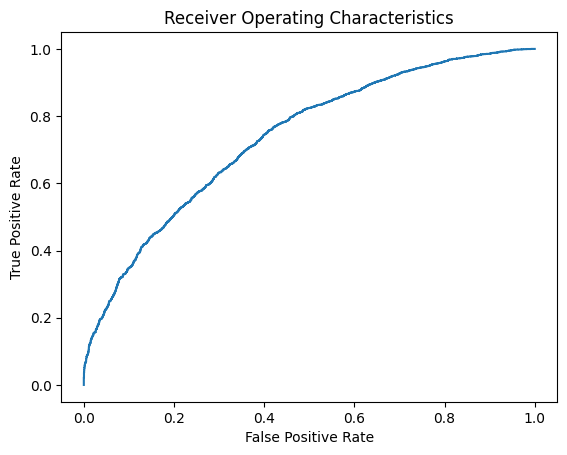

In [9]:
t = 30


dat = list(zip(preds, (y_val > 0).astype(int)))
dat = sorted(dat, key=lambda x: x[0])
pred, label = list(zip(*dat))

spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k=3)
spline_fit = np.clip(spline_model(np.clip(preds, -t, t)), 0, 1)

print(f"brier: {brier_score_loss(np.array(y_val)>0, spline_fit)}")

pred_binary = [1 if x_pred > 0.5 else 0 for x_pred in spline_fit]

print(f"acc: {accuracy_score(np.array(y_val)>0, pred_binary)}")
print(f"roc: {roc_auc_score(np.array(y_val)>0, spline_fit)}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(np.array(y_val)>0, spline_fit)  # Use probabilities
plt.plot(fpr, tpr)
plt.title("Receiver Operating Characteristics")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


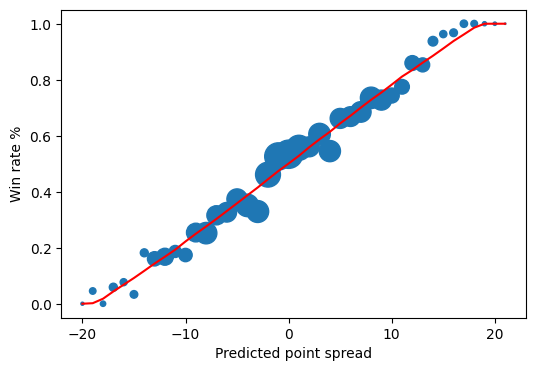

In [10]:
# win margin model predictions and win probability spline fit on the same plot
df = pd.DataFrame({'pred': np.round(preds,0), 
                   'label': np.array(y_val)>0, 
                   'spline_fit': spline_fit})
df = df.groupby('pred')[['label', 'spline_fit']].agg(['mean', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize = (6,4))
ax1.scatter(df['pred'], df['label']['mean'], df['label']['count'])
ax1.plot(df['pred'], df['spline_fit']['mean'], 'r')
ax1.set_xlabel('Predicted point spread')
ax1.set_ylabel('Win rate %')
plt.show()

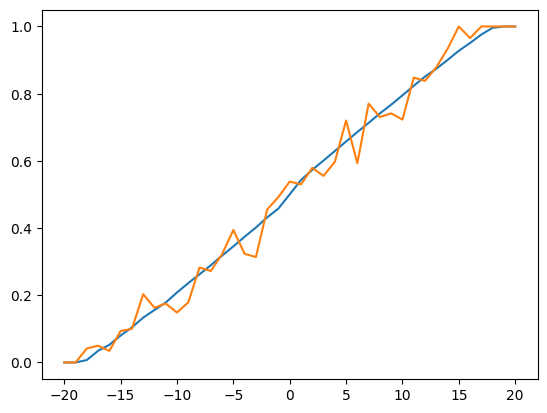

In [11]:
plot_df = pd.DataFrame({"pred": preds, "label": (np.array(y_val) > 0).astype(int), "spline": spline_fit})

plot_df["pred_int"] = plot_df["pred"].astype(int)
plot_df = plot_df.groupby('pred_int')[['spline', 'label']].mean().reset_index()


plt.figure()
plt.plot(plot_df.pred_int,plot_df.spline)
plt.plot(plot_df.pred_int,plot_df.label)

In [12]:
results_df = pd.DataFrame({
    'Level' :  x_val[:,1],
    'Actual': (y_val > 0).astype(int),
    'Actual Spread': y_val,
    'Predicted Spread': preds,
    'Predicted': spline_fit,
    'A_Odds': odds_df.loc[idx_val, 'a_odds'].values,
    'B_Odds': odds_df.loc[idx_val, 'b_odds'].values
}, index=idx_val)

results_df.head()

,Level,Actual,Actual Spread,Predicted Spread,Predicted,A_Odds,B_Odds
11186,1.0,1,5.0,5.462032,0.656747,1.49,2.63
32803,1.0,1,18.0,6.759333,0.693181,1.40,2.90
15596,1.0,0,-0.0,-4.526176,0.372393,2.49,1.53
14931,6.0,0,-26.0,-14.115578,0.113994,7.30,1.09
16740,1.0,0,-20.0,-11.965867,0.169183,4.56,1.20


In [13]:
# Kelly Criterion
def kelly_criterion(vegas_odds, calculated_probability):
    corrected = vegas_odds - 1
    # Calculate the Kelly fraction
    kelly_fraction = calculated_probability - ((1 - calculated_probability)/corrected)
    # Ensure that the fraction is not negative
    kelly_fraction = max(0, kelly_fraction)
    
    return kelly_fraction

In [14]:
better = 0
total_won = 0
diff_fav = 0
bet_correct = 0

upset_predict = 0
upset_correct = 0
upset_won = 0

model_correct = 0
vegas_correct = 0
vegas_total = 0

wrong = 0
comparison_df = results_df.dropna()
length = len(comparison_df)

avg_bet = 0

confidence_pct = .5
confidence_top_pct = 1

START_UNIT = 10
UNIT = START_UNIT

for i, row in comparison_df.iterrows():
    current = START_UNIT
    # if row["Level"] == 6:
    if confidence_top_pct > row['Predicted'] > confidence_pct :
        kelly = (kelly_criterion(row['A_Odds'], row['Predicted']) * UNIT)
        better += 1 if kelly > 0 else 0
        avg_bet += kelly_criterion(row['A_Odds'], row['Predicted'])
        if(row['Actual'] == 1):
            bet_correct += 1 if kelly > 0 else 0
            START_UNIT += (row['A_Odds']-1) * kelly
        else:
            wrong += 1 if kelly > 0 else 0
            START_UNIT -= kelly

    if 1-confidence_top_pct < row['Predicted'] < 1-confidence_pct :
        kelly = (kelly_criterion(row['B_Odds'], 1-row['Predicted']) * UNIT)
        better += 1 if kelly > 0 else 0
        avg_bet += kelly_criterion(row['B_Odds'], 1-row['Predicted'])
        if(row['Actual'] == 0):
            bet_correct += 1 if kelly > 0 else 0
            START_UNIT += (row['B_Odds']-1) * kelly
        else:
            wrong += 1 if kelly > 0 else 0
            START_UNIT -= kelly

    if round(row['Predicted']) != round(1/row['A_Odds']):
        diff_fav += 1

        kelly_A  = (kelly_criterion(row['A_Odds'],row['Predicted']) * UNIT)
        kelly_B  = (kelly_criterion(row['B_Odds'],1-row['Predicted']) * UNIT)

        upset_predict += 1 if (kelly_A > 0 and round(row['Predicted']) == 1) or (kelly_B > 0 and round(row['Predicted']) == 0) else 0

        if round(row['Predicted']) == round(row['Actual']):
            if(row['Actual'] == 1):
                upset_correct += 1 if kelly_A > 0 else 0
                upset_won += (row['A_Odds']-1) * kelly_A
            else:
                upset_correct += 1 if kelly_B > 0 else 0
                upset_won += (row['B_Odds']-1) * kelly_B
        elif round(row['Predicted']) == 1:
            upset_won -= kelly_A
        else:
            upset_won -= kelly_B
            
    if row['Actual']==1 and row['A_Odds'] < row['B_Odds']:
        # print(f"A odds : {row['a_odds']} B odds : {row['b_odds']}")
        vegas_correct += 1

    if row['Actual']==0 and row['A_Odds'] > row['B_Odds']:
        vegas_correct += 1

    if round(row['Predicted']) == round(row['Actual']):
        model_correct += 1


print(f"Total returned on Starting ${UNIT} bankroll: {START_UNIT:.2f} on a total # bets: {better} from a total of {length} games")
print(f"ROI : {((START_UNIT-UNIT)/UNIT):.1f} X")
print(f"Avg Bankroll Bet % : {(avg_bet/better):.3f} %") if better > 0 else print("", end="")
print(f"Amount of differing favorites %: {(diff_fav/length):.3f}")
print(f"Amount of upset bets correct % : {(upset_correct/upset_predict):.3f} with Unit ${UNIT} won ${upset_won:.2f} on {upset_predict} bets")
print(f"Amount of incorrect bet % : {(wrong/better):.4f}") if better > 0 else print("", end="")
print(f"Correct Bet %: {(bet_correct/better):.4f}") if better > 0 else print("", end="")
print(f"Model % Correct : {(model_correct/length):.4f} Vegas Correct % : {(vegas_correct/length):.4f}")


Total returned on Starting $10 bankroll: -10.71 on a total # bets: 1181 from a total of 5937 games
ROI : -2.1 X
Avg Bankroll Bet % : 0.109 %
Amount of differing favorites %: 0.070
Amount of upset bets correct % : 0.433 with Unit $10 won $-27.64 on 268 bets
Amount of incorrect bet % : 0.3294
Correct Bet %: 0.6706
Model % Correct : 0.6660 Vegas Correct % : 0.6705


In [15]:
# # sanity check to check for win probability distribution
# m = X.loc[(~pd.isnull(X.T1_seed)) & (~pd.isnull(X.T2_seed))]
# plt.figure(figsize=(6, 3))
# plt.xlim(0, 1)
# sns.histplot(m['Pred'], bins=42)